# Stock smarter—not simply more
## A retail inventory story from recorded sales
**Jacob Paul · Springboard Data Storytelling · Retail Demand Forecasting Capstone**

**Audience:** a small retailer's owner and inventory/operations manager.  
**Decision:** where should limited planning time and inventory attention go before a busy trading period?  
**Scope:** this is a historical case study of one retailer, not a forecast or a claim of proven inventory savings.

### The story in one minute
November 2011 recorded **2.1×** the average monthly units of January–June. But demand planning cannot stop at the total: **20% of products generated 76.7% of units**, while the typical January-selling product had **15 of 42 later weeks with no recorded sales**.

**Recommendation:** prioritize frequent review of high-volume products and use a separate, cautious approach for intermittently selling items. A blanket inventory increase is not justified by the aggregate rise.

### Questions we asked
1. When did recorded sales intensify?
2. How concentrated were unit sales across products?
3. Did leading products follow the same monthly pattern?
4. How often did established products have weeks without recorded sales?

### Reading the evidence
A unit is an item recorded on a positive merchandise invoice line. We retain missing customer IDs, consistent with the current capstone EDA. Cancellations, adjustments, non-positive quantities/prices, exact duplicates and non-merchandise codes are excluded. The charts therefore show **gross positive merchandise sales**, not net sales, inventory depletion or unconstrained customer demand. Positive invoices later cancelled are not matched to their reversals.

Main monthly comparisons use **January–November 2011**, avoiding the partial December 2011 and keeping one consistent 11-month window. One annual cycle cannot establish recurring seasonality or a holiday cause.

## Reproduce the story
Run all cells from the top. The notebook reads the existing `data/Online Retail.xlsx` file in your capstone repository and writes figures and small evidence tables to `reports/storytelling/`. Initial installation needs internet only if a required package is missing.

In [1]:
import sys, subprocess, importlib.util
packages = {'pandas':'pandas','numpy':'numpy','matplotlib':'matplotlib','openpyxl':'openpyxl'}
missing = [package for module,package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable,'-m','pip','install',*missing])
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter
from IPython.display import display, Markdown

candidates = [Path.cwd(),Path.cwd().parent]
ROOT = next((p for p in candidates if (p/'data/Online Retail.xlsx').is_file()),None)
if ROOT is None:
    raise FileNotFoundError('Place this notebook in the repository notebooks/ folder, with data/Online Retail.xlsx at the repository root.')
OUT = ROOT/'reports/storytelling';OUT.mkdir(parents=True,exist_ok=True)
TEAL, LIGHT, INK, ORANGE = '#007F78','#BADFD9','#18323E','#D97924'
plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.spines.top':False,'axes.spines.right':False,
                     'axes.labelcolor':INK,'text.color':INK,'axes.titleweight':'bold'})
def save_chart(name):
    plt.savefig(OUT/name,dpi=160,bbox_inches='tight')
    plt.show()
print('Source:',ROOT/'data/Online Retail.xlsx')

Source: /Users/jacobpaul/Documents/SpringBoard/Github/retail-demand-forecasting-capstone/data/Online Retail.xlsx


In [2]:
raw = pd.read_excel(ROOT/'data/Online Retail.xlsx',engine='openpyxl')
df = raw.copy()
df['InvoiceNo'] = df.InvoiceNo.astype(str).str.strip()
df['StockCode'] = df.StockCode.astype(str).str.strip()
audit = []
def retain(frame,mask,label):
    result=frame.loc[mask].copy()
    audit.append({'step':label,'removed_rows':len(frame)-len(result),'remaining_rows':len(result)})
    return result
df=retain(df,~df.InvoiceNo.str.startswith(('C','A')),'Exclude cancellation/adjustment invoices')
df=retain(df,df.Quantity.gt(0),'Keep positive quantities')
df=retain(df,df.UnitPrice.gt(0),'Keep positive prices')
df=retain(df,~df.duplicated(),'Remove exact duplicates')
df=retain(df,df.StockCode.str.contains(r'\d',regex=True),'Keep merchandise-code proxy: contains a digit')
cleaning_audit=pd.DataFrame(audit)
period=df.loc[df.InvoiceDate.ge('2011-01-01') & df.InvoiceDate.lt('2011-12-01')].copy()
period['Month']=period.InvoiceDate.dt.to_period('M')
period['Week']=period.InvoiceDate.dt.to_period('W-SUN').dt.start_time
period['GrossSalesValue']=period.Quantity*period.UnitPrice
monthly=period.groupby('Month').agg(units=('Quantity','sum'),invoice_count=('InvoiceNo','nunique'),gross_sales_value=('GrossSalesValue','sum'))
product_units=period.groupby('StockCode').Quantity.sum().sort_values(ascending=False)
assert len(raw)==541909 and len(df)==522685
assert len(monthly)==11 and monthly.units.sum()==product_units.sum()==period.Quantity.sum()
assert period.Quantity.gt(0).all() and period.UnitPrice.gt(0).all()
print(f'Raw: {len(raw):,} invoice lines | cleaned: {len(df):,} | Jan–Nov: {len(period):,}')
print(f'Jan–Nov units: {period.Quantity.sum():,} | distinct products: {len(product_units):,}')
print(f'Missing customer IDs retained in all cleaned data: {df.CustomerID.isna().sum():,}')

Raw: 541,909 invoice lines | cleaned: 522,685 | Jan–Nov: 457,090
Jan–Nov units: 4,891,273 | distinct products: 3,815
Missing customer IDs retained in all cleaned data: 131,402


## 1. The busy period calls for preparation
**Question:** when did recorded sales intensify?  
**Comparison:** monthly gross units; the reference line is the unweighted mean of the six complete months January–June.

The rise begins before November. This is a reason to plan earlier, but the historical pattern alone does not justify a fixed stock multiplier for next year.

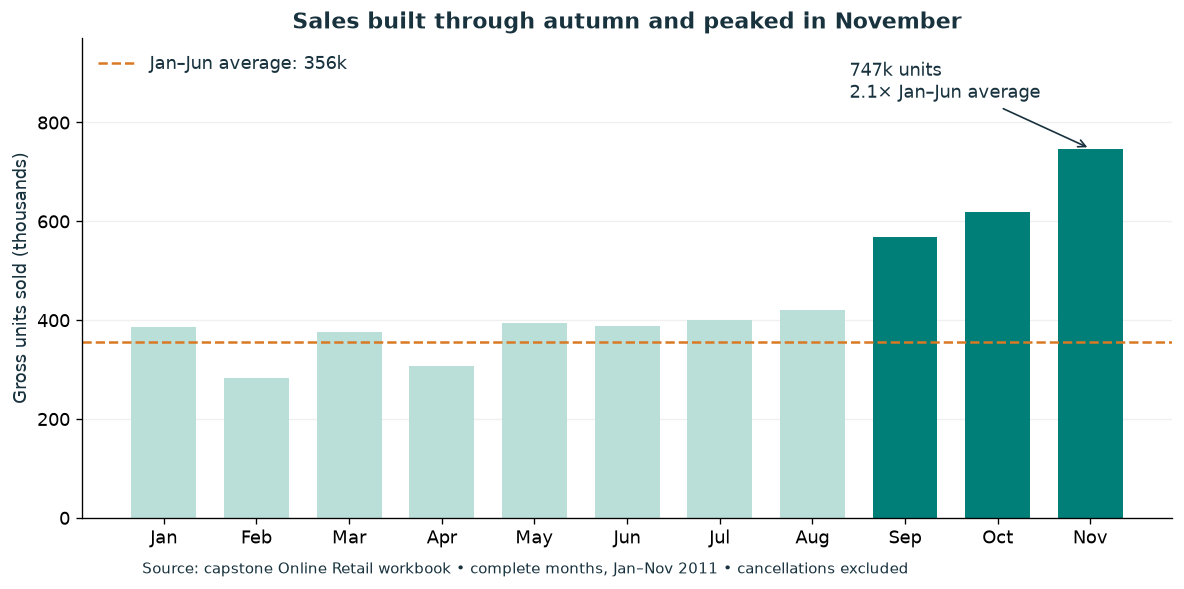

**Finding:** November recorded **746,974 units**, compared with a January–June monthly average of **355,999**. **Implication:** schedule a pre-peak product review; do not interpret 2.1× as a prescribed inventory increase.

In [3]:
first_half_average=monthly.iloc[:6].units.mean()
november_units=int(monthly.loc[pd.Period('2011-11'),'units'])
november_ratio=november_units/first_half_average
fig,ax=plt.subplots(figsize=(10,4.8))
colors=[TEAL if month.month>=9 else LIGHT for month in monthly.index]
ax.bar(np.arange(11),monthly.units/1000,color=colors,width=.7)
ax.axhline(first_half_average/1000,color=ORANGE,linestyle='--',label=f'Jan–Jun average: {first_half_average/1000:.0f}k')
ax.annotate(f'{november_units/1000:.0f}k units\n{november_ratio:.1f}× Jan–Jun average',xy=(10,november_units/1000),xytext=(7.4,850),arrowprops={'arrowstyle':'->','color':INK},fontsize=11)
ax.set(xticks=range(11),xticklabels=[m.strftime('%b') for m in monthly.index],ylabel='Gross units sold (thousands)',ylim=(0,970),title='Sales built through autumn and peaked in November')
ax.legend(loc='upper left',frameon=False);ax.grid(axis='y',alpha=.18);ax.set_axisbelow(True)
fig.text(.125,-.01,'Source: capstone Online Retail workbook • complete months, Jan–Nov 2011 • cancellations excluded',fontsize=9)
plt.tight_layout();save_chart('01_monthly_units.png')
display(Markdown(f'**Finding:** November recorded **{november_units:,} units**, compared with a January–June monthly average of **{first_half_average:,.0f}**. **Implication:** schedule a pre-peak product review; do not interpret {november_ratio:.1f}× as a prescribed inventory increase.'))

## 2. Most unit sales come from a minority of products
**Question:** where should limited planning attention go?  
Products are ranked by total Jan–Nov units. This is a retrospective prioritization lens; it is not a forecast and does not measure margin, carrying cost or stockout cost.

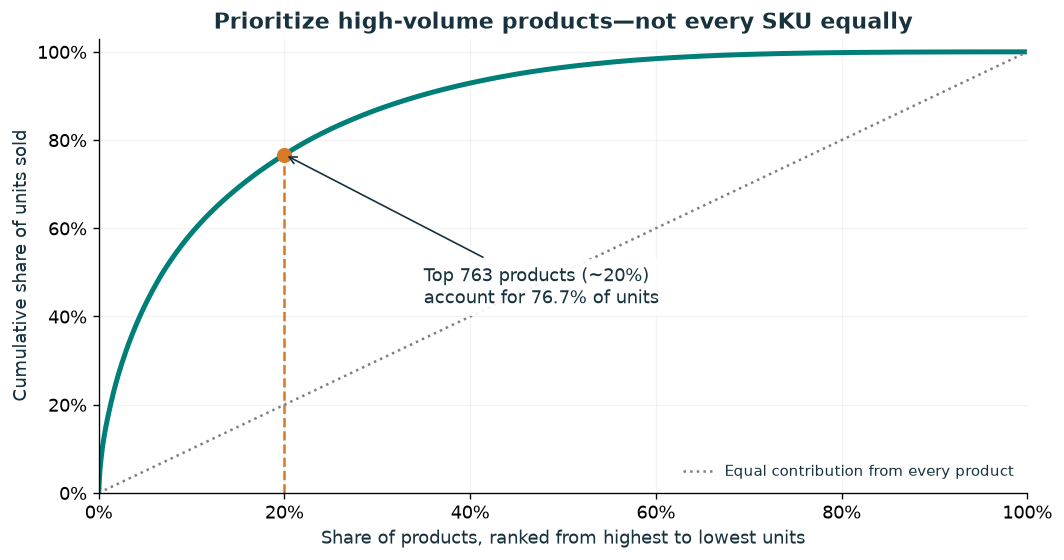

**Finding:** **763 of 3,815 products** generated **76.7%** of units. **Implication:** start a focused replenishment-review pilot, then combine volume with margin, lead time and service criticality before assigning inventory budgets.

In [4]:
top_count=math.ceil(.20*len(product_units))
top_share=product_units.iloc[:top_count].sum()/product_units.sum()
x=np.r_[0,np.arange(1,len(product_units)+1)/len(product_units)]
y=np.r_[0,product_units.cumsum().to_numpy()/product_units.sum()]
fig,ax=plt.subplots(figsize=(9,4.8))
ax.plot(x,y,color=TEAL,linewidth=3)
ax.plot([0,1],[0,1],linestyle=':',color='gray',label='Equal contribution from every product')
ax.scatter(top_count/len(product_units),top_share,color=ORANGE,s=65,zorder=3)
ax.vlines(top_count/len(product_units),0,top_share,color=ORANGE,linestyle='--')
ax.annotate(f'Top {top_count:,} products (~20%)\naccount for {top_share:.1%} of units',xy=(top_count/len(product_units),top_share),xytext=(.35,.43),bbox={'facecolor':'white','edgecolor':'none','alpha':.9},arrowprops={'arrowstyle':'->','color':INK})
ax.set(xlim=(0,1),ylim=(0,1.03),xlabel='Share of products, ranked from highest to lowest units',ylabel='Cumulative share of units sold',title='Prioritize high-volume products—not every SKU equally')
ax.xaxis.set_major_formatter(PercentFormatter(1));ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend(loc='lower right',frameon=False,fontsize=9)
ax.grid(alpha=.15);plt.tight_layout();save_chart('02_product_concentration.png')
display(Markdown(f'**Finding:** **{top_count:,} of {len(product_units):,} products** generated **{top_share:.1%}** of units. **Implication:** start a focused replenishment-review pilot, then combine volume with margin, lead time and service criticality before assigning inventory budgets.'))

## 3. A rising total does not describe every leading product
**Question:** do leading products share the same monthly pattern?  
The six examples are selected by **January–June units only**, before viewing July–November. Each row is indexed to its own January–June monthly mean (1.0). Thus the chart compares patterns, not absolute product volumes. Missing monthly sales are zero recorded units; this does not establish product availability.

The orange divider separates the selection period (Jan–Jun) from the later months. Cell values are rounded to one decimal: 0.0 can represent a small nonzero value. The exceptional January spike for product 23166 needs invoice-level review; it should not be assumed to represent recurring demand.

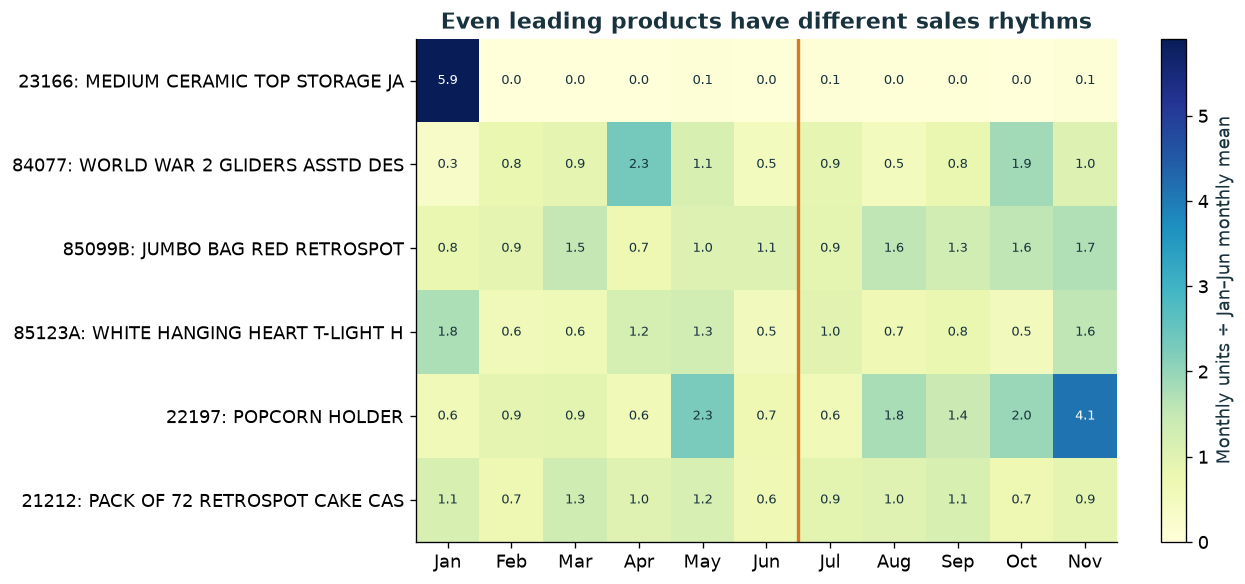

**Finding:** the selected leading items do not move in lockstep. Values above 1.0 exceed that product’s early-year monthly average; values below 1.0 fall short. **Implication:** use product histories alongside the retailer-wide calendar signal. These six examples illustrate heterogeneity; they do not describe every product.

In [5]:
early=period.loc[period.Month.le(pd.Period('2011-06'))]
example_products=early.groupby('StockCode').Quantity.sum().sort_values(ascending=False).head(6).index
product_month=period.groupby(['StockCode','Month']).Quantity.sum().unstack('Month').reindex(index=example_products,columns=monthly.index).fillna(0)
index_values=product_month.div(product_month.iloc[:,:6].mean(axis=1),axis=0)
assert np.isfinite(index_values.to_numpy()).all()
# Use the most common observed description only as a human-readable label.
descriptions=period.groupby('StockCode').Description.agg(lambda s:s.dropna().mode().iloc[0] if not s.dropna().mode().empty else 'Unknown')
labels=[f'{sku}: {str(descriptions.loc[sku])[:29]}' for sku in example_products]
fig,ax=plt.subplots(figsize=(11,5))
im=ax.imshow(index_values.to_numpy(),aspect='auto',cmap='YlGnBu',vmin=0,vmax=float(index_values.to_numpy().max()))
ax.set(xticks=range(11),xticklabels=[m.strftime('%b') for m in monthly.index],yticks=range(6),yticklabels=labels,title='Even leading products have different sales rhythms')
for row in range(6):
 for col in range(11):
  value=index_values.iloc[row,col];ax.text(col,row,f'{value:.1f}',ha='center',va='center',fontsize=8,color='white' if value>index_values.to_numpy().max()*.55 else INK)
ax.axvline(5.5,color=ORANGE,linewidth=2)
fig.colorbar(im,ax=ax,label='Monthly units ÷ Jan–Jun monthly mean')
plt.tight_layout();save_chart('03_product_patterns.png')
display(Markdown('**Finding:** the selected leading items do not move in lockstep. Values above 1.0 exceed that product’s early-year monthly average; values below 1.0 fall short. **Implication:** use product histories alongside the retailer-wide calendar signal. These six examples illustrate heterogeneity; they do not describe every product.'))

## 4. Weeks without sales are common among established products
**Question:** how reliable is the assumption that an established item sells every week?  
Define the cohort once: **all products with at least one positive sale in January 2011**. Follow each through the same **42 complete Monday–Sunday weeks, 7 February–27 November**, including weeks after its last observed sale. This avoids dropping later zero-sales weeks simply because a product stops appearing.

A zero means **no positive sales were recorded in that week**. It might reflect low demand, stockout, retirement, closure or incomplete records. We cannot separate these explanations here.

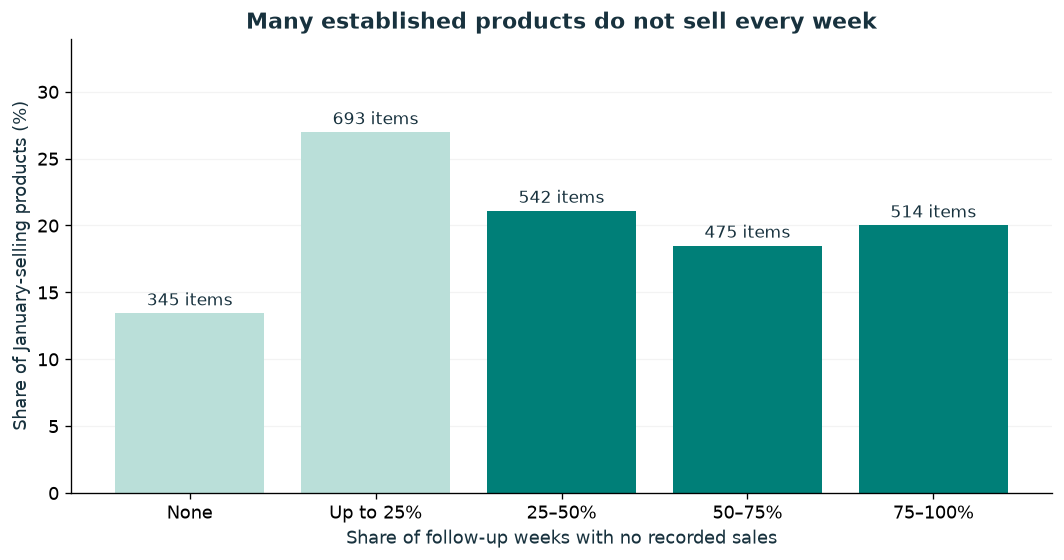

**Finding:** among **2,569 January-selling products**, the median had **15 of 42 weeks (35.7%)** without recorded sales. **59.6%** had no sales in at least one quarter of follow-up weeks. **Implication:** investigate availability and lifecycle status before treating these zeros as low customer demand or replenishing automatically.

In [6]:
cohort=sorted(period.loc[period.Month.eq(pd.Period('2011-01')),'StockCode'].unique())
weeks=pd.date_range('2011-02-07','2011-11-21',freq='W-MON')
weekly=period.groupby(['StockCode','Week']).Quantity.sum().unstack('Week').reindex(index=cohort,columns=weeks).fillna(0)
zero_counts=weekly.eq(0).sum(axis=1)
zero_fraction=zero_counts/len(weeks)
assert len(weeks)==42 and len(weekly)==len(cohort)
assert weekly.to_numpy().min()>=0
buckets=pd.cut(zero_fraction,bins=[-.01,0,.25,.5,.75,1],labels=['None','Up to 25%','25–50%','50–75%','75–100%'])
bucket_counts=buckets.value_counts(sort=False)
assert bucket_counts.sum()==len(cohort)
fig,ax=plt.subplots(figsize=(9,4.8))
bars=ax.bar(bucket_counts.index.astype(str),100*bucket_counts/len(cohort),color=[LIGHT,LIGHT,TEAL,TEAL,TEAL])
for bar,count in zip(bars,bucket_counts):ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.6,f'{count:,} items',ha='center',fontsize=10)
ax.set(ylim=(0,max(100*bucket_counts/len(cohort))+7),xlabel='Share of follow-up weeks with no recorded sales',ylabel='Share of January-selling products (%)',title='Many established products do not sell every week')
ax.grid(axis='y',alpha=.15);ax.set_axisbelow(True);plt.tight_layout();save_chart('04_zero_sales_weeks.png')
display(Markdown(f'**Finding:** among **{len(cohort):,} January-selling products**, the median had **{zero_counts.median():.0f} of {len(weeks)} weeks ({zero_fraction.median():.1%})** without recorded sales. **{zero_fraction.ge(.25).mean():.1%}** had no sales in at least one quarter of follow-up weeks. **Implication:** investigate availability and lifecycle status before treating these zeros as low customer demand or replenishing automatically.'))

## The decision: segment the planning process

| Evidence | Proposed action | What to measure before expanding |
|---|---|---|
| Sales intensified before November | Hold an earlier pre-peak review of product forecasts and supplier capacity | Forecast bias and stock availability; compare against a baseline |
| About one fifth of products generated most units | Pilot weekly review for high-volume products, adjusted for margin and lead-time risk | Service level and inventory value, by segment |
| Leading products followed different paths | Forecast at product-week level; compare against last-week and historical-average baselines | MAE and bias by volume segment |
| Many January-selling products had no-sale weeks | Flag intermittent items; verify stockouts, discontinuations and minimum order quantities | Zero-sales forecast error, stock age and unfilled demand |

**The ask for the operations manager:** approve a limited, measured planning pilot and collect stock-on-hand, stockout flags, lead times and unit costs. These data are needed to translate sales patterns into reorder quantities. We cannot estimate savings, safety stock or optimal stock levels from invoice records alone.

This story supports differentiated attention, not an across-the-board purchase increase.

## What could change the story?

- **Only one retailer and one annual cycle:** the autumn rise is descriptive, not proof of repeatable seasonality or a holiday effect.
- **Gross, not net:** cancellation/return rows are excluded and not matched to original invoices. Bulk orders and later reversals can affect the rankings and totals. Investigate them rather than silently deleting them.
- **No availability history:** a zero-sales week cannot distinguish low demand from stockout or discontinuation. The fixed cohort intentionally retains discontinued items.
- **Selection and units:** the concentration chart uses all 11 months retrospectively; the product-pattern examples use early-year ranking. Units do not measure profitability or capital exposure.
- **One dominant market:** these results represent this retailer's mix, not all small businesses.
- **Model evaluation:** this descriptive story uses January–November outcomes, including periods reserved for modeling validation/test. Do not use these results to repeatedly tune against the final test set; future model claims need a locked evaluation or new data.

The prior EDA's suggestion of a closure around year-end is not established by these invoice records. Here we describe missing sales without assigning an unverified cause.

In [7]:
uk_share=period.loc[period.Country.eq('United Kingdom'),'Quantity'].sum()/period.Quantity.sum()
largest_line=period.Quantity.max()/period.Quantity.sum()
display(Markdown(f'**Context checks:** the United Kingdom represents **{uk_share:.1%}** of Jan–Nov units. The largest single retained invoice line contributes **{largest_line:.1%}** of units, illustrating why bulk-order review matters.'))
cleaning_audit.to_csv(OUT/'cleaning_audit.csv',index=False)
monthly.to_csv(OUT/'monthly_sales.csv')
product_units.rename('units').to_csv(OUT/'product_units.csv')
product_month.to_csv(OUT/'example_product_monthly_units.csv')
pd.DataFrame({'zero_sales_weeks':zero_counts,'followup_weeks':len(weeks),'zero_fraction':zero_fraction}).to_csv(OUT/'established_product_zero_weeks.csv')
summary=pd.DataFrame({'metric':['raw_rows','cleaned_rows','jan_nov_rows','jan_nov_units','distinct_products','november_units','jan_jun_mean_monthly_units','november_ratio','top_20pct_product_count','top_20pct_unit_share','january_cohort_products','followup_weeks','median_zero_weeks','uk_unit_share'],
'value':[len(raw),len(df),len(period),period.Quantity.sum(),len(product_units),november_units,first_half_average,november_ratio,top_count,top_share,len(cohort),len(weeks),zero_counts.median(),uk_share]})
summary.to_csv(OUT/'story_metrics.csv',index=False)
display(cleaning_audit)
print('All reconciliation checks passed; four figures and six evidence tables saved to reports/storytelling/.')

**Context checks:** the United Kingdom represents **82.6%** of Jan–Nov units. The largest single retained invoice line contributes **1.5%** of units, illustrating why bulk-order review matters.

,step,removed_rows,remaining_rows
0,Exclude cancellation/adjustment invoices,9291,532618
1,Keep positive quantities,1336,531282
2,Keep positive prices,1179,530103
3,Remove exact duplicates,5226,524877
4,Keep merchandise-code proxy: contains a digit,2192,522685


All reconciliation checks passed; four figures and six evidence tables saved to reports/storytelling/.


## Mentor presentation notes (about 5 minutes)

1. **Opening (30 seconds):** “Sales doubled relative to the early-year monthly average. Should we double every product’s stock? The product data says that would be an unsupported leap.”
2. **Timing (45 seconds):** explain the monthly rise and the complete-month comparison; one year does not prove annual recurrence.
3. **Priority (45 seconds):** show the concentration curve. Explain that the first planning pilot should focus attention, not blindly allocate 76.7% of the budget.
4. **Variation (45 seconds):** use the product heatmap to show why a single retailer-wide multiplier misses different item trajectories.
5. **Intermittency (60 seconds):** explain the fixed January cohort, its 42 follow-up weeks and the distinction between zero sales and zero demand.
6. **Close (45 seconds):** ask for a segmented pilot and better inventory data. Explain what you would measure and what this analysis cannot claim.

**Likely mentor questions:** Why keep missing customer IDs? We forecast product units, not customer behavior. Why no hypothesis test? This is a descriptive decision story, and a small p-value would not establish inventory savings or a seasonal cause. Why not prescribe reorder levels? Stock, lead time and cost information are absent.

### Source and assignment coverage
- Dataset: `data/Online Retail.xlsx` from the user's [retail-demand-forecasting-capstone](https://github.com/jacob25paul/retail-demand-forecasting-capstone) repository.
- Cleaning aligned with `notebooks/02_exploratory_data_analysis.ipynb`; fixed follow-up avoids ending a product's observation period at its last sale.
- Original dataset reference: Chen, D. (2015), [Online Retail, UCI](https://doi.org/10.24432/C5BW33); project attribution identifies CC BY 4.0.
- The notebook contains the selected audience, questions, trends, visualizations, conclusions and presentation notes requested in the pasted assignment. The linked Springboard instruction and rubric downloads returned HTTP 403; their additional details could not be checked.

